In [51]:
import numpy as np
import pandas as pd
import sys
import os

In [52]:
data_path = os.path.join(os.getcwd(), 'data/basic recommender data')

In [53]:
credits = pd.read_csv(os.path.join(data_path, 'tmdb_5000_credits.csv'))
movies = pd.read_csv(os.path.join(data_path, 'tmdb_5000_movies.csv'))

In [54]:
credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [55]:
movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [56]:
credits.rename(columns={'movie_id': 'id'}, inplace=True)
credits['id'] = credits['id'].astype(int)
movies['id'] = movies['id'].astype(int)
merged = pd.merge(movies, credits   , on='id', how='left').reset_index(drop=True)
merged.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title_x,vote_average,vote_count,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [57]:
cleaned = merged.drop(columns=['homepage', 'status', 'production_countries', 'title_x', 'title_y'], axis=1)
cleaned.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","Lost in our world, found in another.",6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [58]:
cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   id                    4803 non-null   int64  
 3   keywords              4803 non-null   object 
 4   original_language     4803 non-null   object 
 5   original_title        4803 non-null   object 
 6   overview              4800 non-null   object 
 7   popularity            4803 non-null   float64
 8   production_companies  4803 non-null   object 
 9   release_date          4802 non-null   object 
 10  revenue               4803 non-null   int64  
 11  runtime               4801 non-null   float64
 12  spoken_languages      4803 non-null   object 
 13  tagline               3959 non-null   object 
 14  vote_average          4803 non-null   float64
 15  vote_count           

# 🎯 Weighted Average Recommender Systems

> 💡 **Use Case**: When you want to combine multiple recommendation sources (e.g., content-based + collaborative + popularity) and assign **weights** to their contribution.

---

## 🧠 What Is a Weighted Average Recommender?

A **Weighted Average Recommender System** blends scores from multiple models into a final score.

### 📐 Weighted Score Formula

![Weighted Score Formula](https://latex.codecogs.com/png.image?\dpi{150}&space;\text{Score}(u,&space;i)&space;=&space;w_1&space;\cdot&space;S_1(u,&space;i)&space;+&space;w_2&space;\cdot&space;S_2(u,&space;i)&space;+&space;\dots&space;+&space;w_n&space;\cdot&space;S_n(u,&space;i))

Where:
- ![w_k](https://latex.codecogs.com/png.image?\dpi{110}&space;w_k) = Weight of the k-th recommender
- ![S_k(u, i)](https://latex.codecogs.com/png.image?\dpi{110}&space;S_k(u,&space;i)) = Score predicted by that recommender
- Weights should sum to 1:  
  ![\sum w_k = 1](https://latex.codecogs.com/png.image?\dpi{110}&space;\sum_{k=1}^n&space;w_k&space;=&space;1)

---

## 🧱 Architecture Diagram: Hybrid Weighted Ensemble

![Weighted Average Architecture](https://i.imgur.com/sQUCSNu.png)

### 🔍 Explanation:
- Multiple models (collaborative, content-based, popularity)
- Each model predicts a score
- Scores are combined using weighted average
- Final recommendations are ranked and sent to user

---

## 🧪 Python Code Example

```python
# Scores from different recommenders
collab_score = 0.8
content_score = 0.5
popularity_score = 0.9

# Assigned weights
w_collab = 0.5
w_content = 0.3
w_pop = 0.2

# Final weighted score
final_score = (w_collab * collab_score +
               w_content * content_score +
               w_pop * popularity_score)

print(f"Final weighted score: {final_score:.2f}")
```

**Output**:
```
Final weighted score: 0.71
```

---

## 🎨 When to Use Weighted Average

🟩 **Use When:**
- You have multiple recommenders
- Want simple, explainable fusion
- Each source is equally important or adjustable

🟥 **Avoid When:**
- Model scores aren't normalized
- Relationships are non-linear
- You need deep personalization logic

---

## 🧠 Learnable Weighted Ensemble

Instead of manually assigning weights, we can **learn them**:

![Learned Weighted Sum](https://latex.codecogs.com/png.image?\dpi{150}&space;\hat{y}_{ui}&space;=&space;\theta_1&space;S_1(u,&space;i)&space;+&space;\theta_2&space;S_2(u,&space;i)&space;+&space;\dots&space;+&space;\theta_n&space;S_n(u,&space;i))

- Trainable parameters ![\theta_k](https://latex.codecogs.com/png.image?\dpi{110}&space;\theta_k)
- Use gradient descent or regression to learn best weights

---

## 🧾 Use Case Applications

### 🛒 E-commerce

| Recommender    | Weight | Purpose                         |
|----------------|--------|----------------------------------|
| Collaborative  | 0.4    | Captures user preferences        |
| Content-Based  | 0.3    | Helps new items with metadata    |
| Popularity     | 0.3    | Boosts trending products         |

---

### 🎬 Streaming Platform

| Recommender   | Weight | Role                             |
|---------------|--------|----------------------------------|
| Neural CF     | 0.5    | Personalized recommendations     |
| Genre Match   | 0.2    | Aligns with preferred genres     |
| Recently Watched | 0.3 | Context-aware suggestions        |

---

### 📰 News App

| Recommender     | Weight | Benefit                      |
|-----------------|--------|------------------------------|
| Local News      | 0.2    | Geographic personalization   |
| Collaborative   | 0.4    | Behavior-based preferences   |
| Editorial Picks | 0.4    | Curated trending news        |

---

## 📌 Best Practices

- ✅ Normalize all scores to [0, 1]
- ✅ Use caching for expensive models
- ✅ Log feedback to tune weights over time
- ✅ Use approximate nearest neighbors (Faiss, Annoy) for large item sets

---

## 📌 Related Techniques

- 🧠 **Stacking**: Use a meta-model to learn best blend
- 🎯 **Bandits**: Adjust weights dynamically from feedback
- 🔗 **Hybrid + GenAI**: Use embeddings from LLMs as one component

---

## 🧠 Summary Table

| Concept                    | Description                                         |
|---------------------------|-----------------------------------------------------|
| Weighted Average           | Linear combination of multiple recommenders         |
| Manual or Learnable        | Assign or train weights                             |
| Tools                      | Python, Faiss, LightFM, TensorFlow Recommenders     |
| Output                     | Single ranked list per user                         |
| Explainability             | Clear score attribution from each source            |

---

> ✅ Weighted Average recommenders are **interpretable**, **simple**, and **great for hybrid systems** that blend content, behavior, and popularity signals.



# 🍿 2. IMDB-Style Weighted Average for Recommender Systems

> A **global item ranking technique** that balances **average rating** and **vote count**, ensuring fair comparison across items with different visibility.

---

## 📐 The Formula

![IMDB Weighted Rating Formula](https://latex.codecogs.com/png.image?\dpi{150}&space;WR&space;=&space;\frac{v}{v&plus;m}&space;\cdot&space;R&space;&plus;&space;\frac{m}{v&plus;m}&space;\cdot&space;C)

Where:
- ![R](https://latex.codecogs.com/png.image?\dpi{110}&space;R): average rating of the movie  
- ![v](https://latex.codecogs.com/png.image?\dpi{110}&space;v): number of votes the movie has received  
- ![m](https://latex.codecogs.com/png.image?\dpi{110}&space;m): minimum votes required for ranking  
- ![C](https://latex.codecogs.com/png.image?\dpi{110}&space;C): mean vote across the dataset  
- ![WR](https://latex.codecogs.com/png.image?\dpi{110}&space;WR): weighted rating score

---

## 🧠 Why Use This?

- Ratings with **few votes can be misleading**.
- Popular items get more **stable ratings**.
- This technique **prevents small-sample bias**.

---

## 🧱 Architecture Diagram

![IMDB Weighted Architecture](https://raw.githubusercontent.com/samarthdamle/static-assets/main/imdb_weighted_avg_architecture.png)

### Explanation:
1. Fetch user ratings and item vote counts.
2. Compute dataset-wide average rating `C`.
3. Set a vote threshold `m` (e.g., 80th percentile).
4. Apply the formula to compute **weighted rating** for each item.
5. Rank items by WR for "Top-N", "Trending", or "Editor's Picks".

---

## 🧪 Python Code Example

```python
def imdb_weighted_rating(R, v, m, C):
    """
    R = average rating of movie
    v = number of votes for movie
    m = minimum votes required
    C = mean rating across all movies
    """
    return (v / (v + m)) * R + (m / (v + m)) * C

# Example
R = 8.5    # Movie rating
v = 3000   # Number of votes
m = 2500   # Minimum threshold
C = 7.0    # Global average

score = imdb_weighted_rating(R, v, m, C)
print(f"Weighted Score: {score:.2f}")
```

**Output**:
```
Weighted Score: 7.79
```

---

## 🎯 Real-World Use Cases

| Platform     | Use Case                        | Description                                 |
|--------------|----------------------------------|---------------------------------------------|
| **IMDb**     | Top 250 Movies                  | Weighted rating avoids skew from low-vote films |
| **Netflix**  | Most Watched This Week          | Combine watch count with rating average     |
| **YouTube**  | Trending Videos                 | Boost based on view count + likes           |
| **Product Sites** | Best Reviewed Products     | Based on review count + star rating         |

---

## ✅ Pros and 🔴 Cons

| Pros                               | Cons                                        |
|------------------------------------|---------------------------------------------|
| ✅ Fairer comparison of items       | 🔴 Not personalized                          |
| ✅ Handles low-vote inflation       | 🔴 Doesn’t learn user behavior               |
| ✅ Transparent & interpretable      | 🔴 Doesn't adapt to individual preferences   |

---

## 🟩 When to Use

- "Top 100 Movies"
- "Editor's Picks"
- "Best Rated This Year"
- "Trending Products"
- Anytime you want **global ranking**

🟥 Avoid for:
- Personalized recommendations  
- Dynamic, user-specific scores  
- Large sparse datasets with few votes per item

---

## 🧠 Related Techniques

- **Bayesian average rating**  
- **Wilson score interval** (used in Reddit, Amazon reviews)  
- **Confidence-weighted rankings**  
- **Exponential smoothing over time** (for trending)

---

> ✅ Use **IMDB-style weighted average** when you want to **rank globally**, and avoid misleading high scores from niche items with few votes.


In [59]:
# WR = (Rv + Cm) / (v + m)
# calculate weighted average rating from above formula
v = cleaned['vote_count']
m = cleaned['vote_count'].quantile(0.7)
R = cleaned['vote_average']
C = cleaned['vote_average'].mean()

In [60]:
cleaned['weighted_avg'] = (R * v + C * m) / (v + m)

In [61]:
cleaned.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew,weighted_avg
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.148013
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.807627
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.276075
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.509565
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","Lost in our world, found in another.",6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",6.098319


In [62]:
sorted_cleaned = cleaned.sort_values(by='weighted_avg', ascending=False)
print(sorted_cleaned[['original_title','vote_count', 'vote_average', 'weighted_avg', 'popularity']].head(10))

                original_title  vote_count  vote_average  weighted_avg  \
1881  The Shawshank Redemption        8205           8.5      8.340775   
3337             The Godfather        5893           8.4      8.192887   
662                 Fight Club        9413           8.3      8.171648   
3232              Pulp Fiction        8428           8.3      8.157615   
65             The Dark Knight       12002           8.2      8.102674   
809               Forrest Gump        7927           8.2      8.056059   
1818          Schindler's List        4329           8.3      8.038748   
3865                  Whiplash        4254           8.3      8.034695   
96                   Inception       13752           8.1      8.018611   
1990   The Empire Strikes Back        5879           8.2      8.010426   

      popularity  
1881  136.747729  
3337  143.659698  
662   146.757391  
3232  121.463076  
65    187.322927  
809   138.133331  
1818  104.469351  
3865  192.528841  
96    167.5837

/var/folders/qg/z2td1lnj4h11fd0j883qpjwc0000gn/T/ipykernel_79186/2809710994.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weighted_avg', y='original_title', data=sorted_cleaned.head(10), palette='viridis')


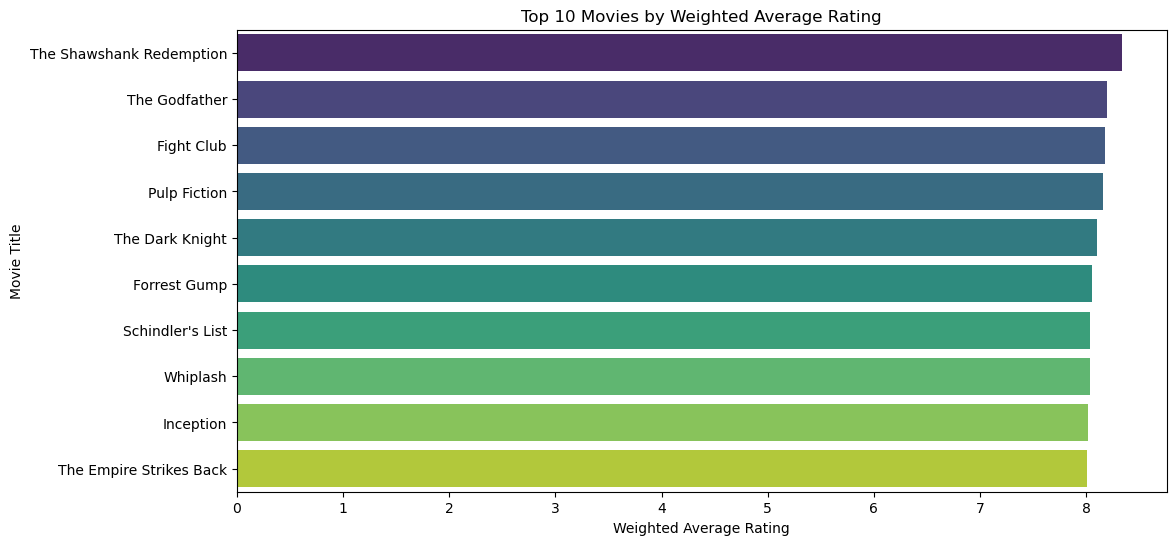

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='weighted_avg', y='original_title', data=sorted_cleaned.head(10), palette='viridis')
plt.title('Top 10 Movies by Weighted Average Rating')
plt.xlabel('Weighted Average Rating')
plt.ylabel('Movie Title')
plt.show()

/var/folders/qg/z2td1lnj4h11fd0j883qpjwc0000gn/T/ipykernel_79186/3550651196.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='popularity', y='original_title', data=popularity.head(10), palette='viridis')


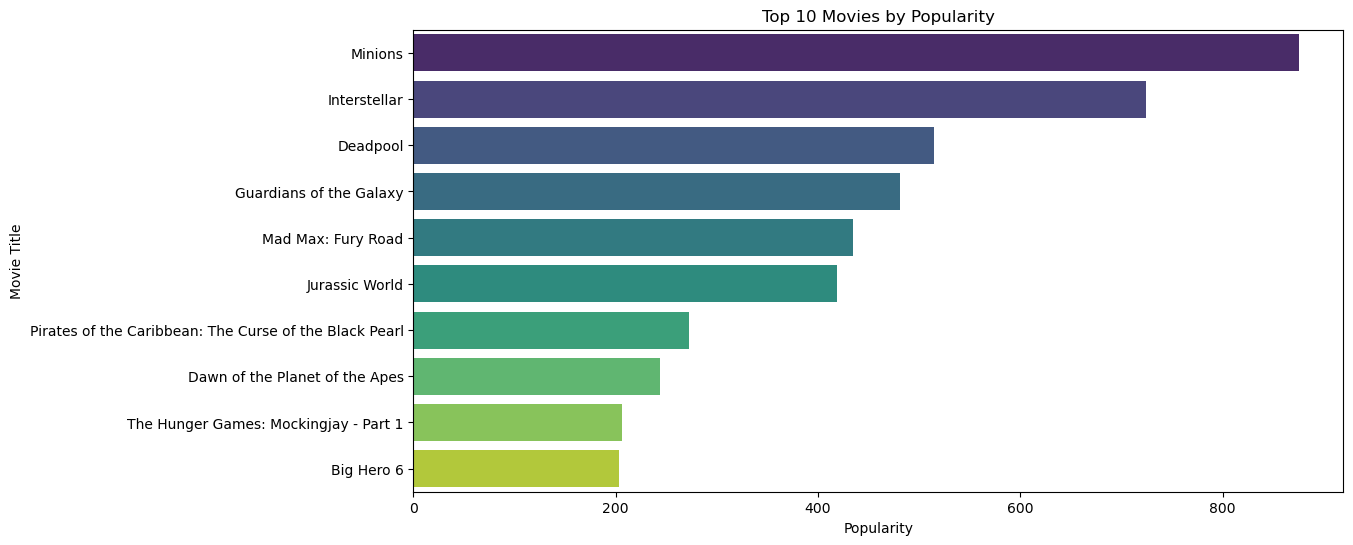

In [64]:
popularity = cleaned.sort_values(by='popularity', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='popularity', y='original_title', data=popularity.head(10), palette='viridis')
plt.title('Top 10 Movies by Popularity')
plt.xlabel('Popularity')
plt.ylabel('Movie Title')
plt.show()

# Recommendation on scaled weighted avg and popularity [weights -> 50% to weighted_avg and 50% to popularity]

In [65]:
from sklearn.preprocessing import MinMaxScaler # scale down values between 0-1

scaler = MinMaxScaler()
movies_scaled = scaler.fit_transform(cleaned[['weighted_avg', 'popularity']])

movies_normalized = pd.DataFrame(movies_scaled, columns=['weighted_avg', 'popularity'])
movies_normalized.head()

,weighted_avg,popularity
0,0.674339,0.171815
1,0.581403,0.158846
2,0.436273,0.122635
3,0.773054,0.128272
4,0.387739,0.050169


In [66]:
# put it back in cleaned dataframe
cleaned[['normalized_weighted_avg', 'normalized_popularity']] = movies_normalized

In [67]:
cleaned['score'] = 0.5 * cleaned['normalized_weighted_avg'] + 0.5 * cleaned['normalized_popularity']
cleaned = cleaned.sort_values(by='score', ascending=False)
cleaned[['original_title', 'vote_count', 'vote_average', 'weighted_avg', 'popularity', 'normalized_weighted_avg', 'normalized_popularity', 'score']].head(10)   

,original_title,vote_count,vote_average,weighted_avg,popularity,normalized_weighted_avg,normalized_popularity,score
95,Interstellar,10867,8.1,7.998100,724.247784,0.906439,0.827162,0.866801
546,Minions,4571,6.4,6.365286,875.581305,0.460630,1.000000,0.730315
94,Guardians of the Galaxy,9742,7.9,7.798252,481.098624,0.851874,0.549462,0.700668
788,Deadpool,10995,7.4,7.334360,514.569956,0.725217,0.587690,0.656453
127,Mad Max: Fury Road,9427,7.2,7.135687,434.278564,0.670973,0.495989,0.583481
1881,The Shawshank Redemption,8205,8.5,8.340775,136.747729,1.000000,0.156179,0.578090
65,The Dark Knight,12002,8.2,8.102674,187.322927,0.934991,0.213941,0.574466
3865,Whiplash,4254,8.3,8.034695,192.528841,0.916431,0.219887,0.568159
3337,The Godfather,5893,8.4,8.192887,143.659698,0.959622,0.164074,0.561848
662,Fight Club,9413,8.3,8.171648,146.757391,0.953823,0.167611,0.560717


In [68]:
# We can now use the 'score' column to recommend movies based on a combination of their weighted average rating and popularity to recommend movies.
# The higher the score, the better the movie is in terms of both rating and popularity.